# Multi-Task LSTM Model Training
This notebook builds and trains a multi-task LSTM model to predict energy demand, detect outages, and classify system alerts.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import time
from pathlib import Path
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import os

# Settings
# Create directories for model checkpoints and artifacts.
os.makedirs('../models/trained', exist_ok=True)
os.makedirs('figures', exist_ok=True)
TRAIN_EPOCHS = int(os.environ.get('TRAIN_EPOCHS', 150))

print(f'TensorFlow Version: {tf.__version__}')
print(f'Training epochs set to: {TRAIN_EPOCHS}')

TensorFlow Version: 2.21.0
Training epochs set to: 2


## Section 1 — Load Data & Oversample Minority Classes

In [2]:
prep_dir = Path('../models/preprocessing')

X_train = np.load(prep_dir / 'X_train.npy')
y_demand_train = np.load(prep_dir / 'y_demand_train.npy')
y_anomaly_train = np.load(prep_dir / 'y_anomaly_train.npy')
y_alert_train = np.load(prep_dir / 'y_alert_train.npy')

X_val = np.load(prep_dir / 'X_val.npy')
y_demand_val = np.load(prep_dir / 'y_demand_val.npy')
y_anomaly_val = np.load(prep_dir / 'y_anomaly_val.npy')
y_alert_val = np.load(prep_dir / 'y_alert_val.npy')

# Fix 1 — Oversampling
outage_idx = np.where(y_anomaly_train == 1)[0]
critical_idx = np.where(y_alert_train == 2)[0]
minority_idx = np.unique(np.concatenate([outage_idx, critical_idx]))

print(f'Original anomaly samples: {len(outage_idx)}')
print(f'Original critical samples: {len(critical_idx)}')

X_extra = X_train[minority_idx]
yd_extra = y_demand_train[minority_idx]
ya_extra = y_anomaly_train[minority_idx]
yl_extra = y_alert_train[minority_idx]

X_train = np.concatenate([X_train] + [X_extra]*20)
y_demand_train = np.concatenate([y_demand_train] + [yd_extra]*20)
y_anomaly_train = np.concatenate([y_anomaly_train] + [ya_extra]*20)
y_alert_train = np.concatenate([y_alert_train] + [yl_extra]*20)

# Shuffle
idx = np.arange(len(X_train))
np.random.seed(42)
np.random.shuffle(idx)
X_train, y_demand_train, y_anomaly_train, y_alert_train = \
    X_train[idx], y_demand_train[idx], y_anomaly_train[idx], y_alert_train[idx]

print(f'New training shape: {X_train.shape}')
print(f'New anomaly samples: {np.sum(y_anomaly_train)}')
print(f'New critical samples: {np.sum(y_alert_train == 2)}')

Original anomaly samples: 337
Original critical samples: 14


New training shape: (31212, 48, 21)
New anomaly samples: 7077
New critical samples: 294


## Section 2 — Model Architecture

In [3]:
# The model uses a sequence length of 48 steps (24 hours at 30-minute intervals)
# and 21 feature channels coming from the preprocessing pipeline.
input_shape = (48, 21)
inputs = layers.Input(shape=input_shape, name='main_input')
x = layers.LSTM(128, return_sequences=True)(inputs)
x = layers.Dropout(0.2)(x)
x = layers.LSTM(64, return_sequences=False)(x)
x = layers.Dropout(0.2)(x)
shared = layers.Dense(32, activation='relu', name='shared_dense')(x)

demand_output = layers.Dense(16, activation='relu')(shared)
demand_output = layers.Dense(8, activation='linear', name='demand_output')(demand_output)
anomaly_output = layers.Dense(8, activation='relu')(shared)
anomaly_output = layers.Dense(1, activation='sigmoid', name='anomaly_output')(anomaly_output)
alert_output = layers.Dense(16, activation='relu')(shared)
alert_output = layers.Dense(3, activation='softmax', name='alert_output')(alert_output)

model = models.Model(inputs=inputs, outputs=[demand_output, anomaly_output, alert_output])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ main_input          │ (None, 48, 21)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 48, 128)   │     76,800 │ main_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 48, 128)   │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 64)        │     49,408 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dense        │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │        528 │ shared_dense[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 8)         │        264 │ shared_dense[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │        528 │ shared_dense[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ demand_output       │ (None, 8)         │        136 │ dense[0][0]       │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ anomaly_output      │ (None, 1)         │          9 │ dense_1[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ alert_output        │ (None, 3)         │         51 │ dense_2[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 129,804 (507.05 KB)

 Trainable params: 129,804 (507.05 KB)

 Non-trainable params: 0 (0.00 B)

## Section 3 — Compile (Updated Loss Weights)

In [4]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), # Fix 4
    loss={
        'demand_output': 'mse',
        'anomaly_output': 'binary_crossentropy',
        'alert_output': 'sparse_categorical_crossentropy'
    },
    loss_weights={
        'demand_output': 0.5,
        'anomaly_output': 4.0,
        'alert_output': 4.0
    },
    metrics={
        'demand_output': 'mae',
        'anomaly_output': 'accuracy',
        'alert_output': 'accuracy'
    }
)

## Section 4 — Callbacks

In [5]:
# Standard callbacks help stabilize training and preserve the best weights.
model_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
    callbacks.ModelCheckpoint('../models/trained/best_model.keras', monitor='val_loss', save_best_only=True),
    callbacks.CSVLogger('../models/trained/training_log.csv')
]

## Section 5 — Train (Per-Sample Weights)

In [6]:
# Fix 3 — Per-sample weights
anomaly_weights = np.where(y_anomaly_train == 1, 30.0, 1.0)
alert_weights = np.where(y_alert_train == 2, 30.0, np.where(y_alert_train == 1, 5.0, 1.0))

# Keras expects one sample weight array per model output when the targets are passed as a list.
sample_weights = [
    np.ones(len(y_demand_train)),
    anomaly_weights,
    alert_weights
]

start_time = time.time()
history = model.fit(
    X_train,
    [y_demand_train, y_anomaly_train, y_alert_train],
    validation_data=(X_val, [y_demand_val, y_anomaly_val, y_alert_val]),
    epochs=TRAIN_EPOCHS,
    batch_size=64,
    sample_weight=sample_weights,
    callbacks=model_callbacks,
    verbose=1
)

end_time = time.time()
print(f'Training finished at {time.ctime()}')
best_epoch = np.argmin(history.history['val_loss'])
print(f'Best epoch: {best_epoch + 1} with val_loss: {history.history["val_loss"][best_epoch]:.4f}')

Epoch 1/2



  1/488 ━━━━━━━━━━━━━━━━━━━━ 1:29:50 11s/step - alert_output_accuracy: 0.7500 - alert_output_loss: 2.6561 - anomaly_output_accuracy: 0.5000 - anomaly_output_loss: 7.9259 - demand_output_loss: 78571.9453 - demand_output_mae: 267.1891 - loss: 39328.3008


  2/488 ━━━━━━━━━━━━━━━━━━━━ 58s 121ms/step - alert_output_accuracy: 0.7383 - alert_output_loss: 2.4834 - anomaly_output_accuracy: 0.4688 - anomaly_output_loss: 7.1329 - demand_output_loss: 77738.8242 - demand_output_mae: 265.4723 - loss: 38907.8770  


  3/488 ━━━━━━━━━━━━━━━━━━━━ 53s 111ms/step - alert_output_accuracy: 0.7509 - alert_output_loss: 2.3019 - anomaly_output_accuracy: 0.4444 - anomaly_output_loss: 6.7261 - demand_output_loss: 75640.1979 - demand_output_mae: 261.5184 - loss: 37856.2109


  4/488 ━━━━━━━━━━━━━━━━━━━━ 53s 112ms/step - alert_output_accuracy: 0.7575 - alert_output_loss: 2.2222 - anomaly_output_accuracy: 0.4300 - anomaly_output_loss: 6.6060 - demand_output_loss: 75074.0508 - demand_output_mae: 260.4592 - loss: 37572.3389

...


486/488 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - alert_output_accuracy: 0.7724 - alert_output_loss: 1.7590 - anomaly_output_accuracy: 0.2264 - anomaly_output_loss: 2.5599 - demand_output_loss: 7790.2231 - demand_output_mae: 78.4869 - loss: 3912.3873


487/488 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - alert_output_accuracy: 0.7724 - alert_output_loss: 1.7590 - anomaly_output_accuracy: 0.2264 - anomaly_output_loss: 2.5599 - demand_output_loss: 7790.0902 - demand_output_mae: 78.4867 - loss: 3912.3207


488/488 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - alert_output_accuracy: 0.7724 - alert_output_loss: 1.7590 - anomaly_output_accuracy: 0.2264 - anomaly_output_loss: 2.5599 - demand_output_loss: 7789.9562 - demand_output_mae: 78.4864 - loss: 3912.2538


488/488 ━━━━━━━━━━━━━━━━━━━━ 50s 103ms/step - alert_output_accuracy: 0.7790 - alert_output_loss: 1.7562 - anomaly_output_accuracy: 0.2267 - anomaly_output_loss: 2.5491 - demand_output_loss: 7724.7158 - demand_output_mae: 78.3722 - loss: 3879.6951 - val_alert_output_accuracy: 0.9937 - val_alert_output_loss: 0.9189 - val_anomaly_output_accuracy: 0.0131 - val_anomaly_output_loss: 2.5243 - val_demand_output_loss: 8614.9326 - val_demand_output_mae: 82.9945 - val_loss: 4325.9307 - learning_rate: 5.0000e-04


Training finished at Thu May 21 17:18:11 2026
Best epoch: 2 with val_loss: 4325.9307


## Section 6 — Training Curves

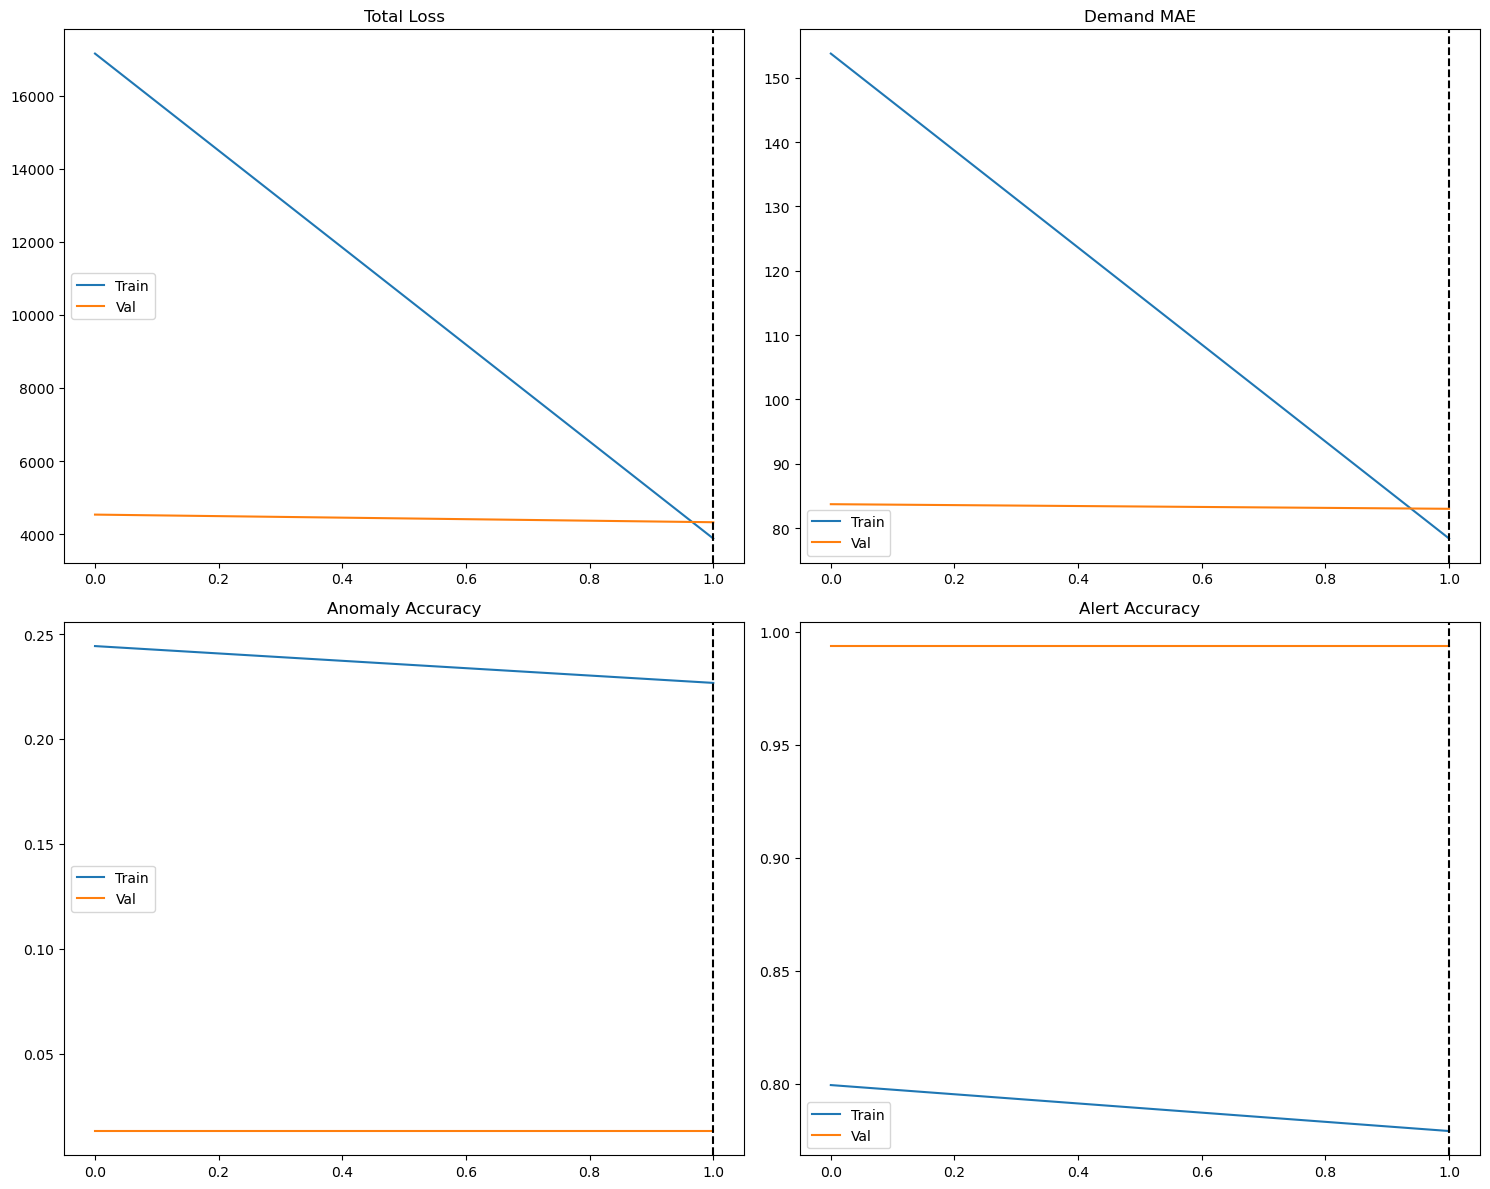

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
best_epoch = np.argmin(history.history['val_loss'])

# Total Loss
axes[0,0].plot(history.history['loss'], label='Train')
axes[0,0].plot(history.history['val_loss'], label='Val')
axes[0,0].axvline(best_epoch, color='black', linestyle='--')
axes[0,0].set_title('Total Loss')
axes[0,0].legend()

# Demand MAE
axes[0,1].plot(history.history['demand_output_mae'], label='Train')
axes[0,1].plot(history.history['val_demand_output_mae'], label='Val')
axes[0,1].axvline(best_epoch, color='black', linestyle='--')
axes[0,1].set_title('Demand MAE')
axes[0,1].legend()

# Anomaly Accuracy
axes[1,0].plot(history.history['anomaly_output_accuracy'], label='Train')
axes[1,0].plot(history.history['val_anomaly_output_accuracy'], label='Val')
axes[1,0].axvline(best_epoch, color='black', linestyle='--')
axes[1,0].set_title('Anomaly Accuracy')
axes[1,0].legend()

# Alert Accuracy
axes[1,1].plot(history.history['alert_output_accuracy'], label='Train')
axes[1,1].plot(history.history['val_alert_output_accuracy'], label='Val')
axes[1,1].axvline(best_epoch, color='black', linestyle='--')
axes[1,1].set_title('Alert Accuracy')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('figures/training_curves.png')
plt.show()

## Section 7 — Save

In [8]:
model.save('../models/trained/final_model.keras')

with open('../models/trained/history.json', 'w') as f:
    json.dump({k: [float(v1) for v1 in v] for k, v in history.history.items()}, f)

print('Models and history saved to models/trained/')

print('\nFinal Metrics (Val):')
for k, v in history.history.items():
    if k.startswith('val_'):
        print(f'{k}: {v[best_epoch]:.4f}')

Models and history saved to models/trained/

Final Metrics (Val):
val_alert_output_accuracy: 0.9937
val_alert_output_loss: 0.9189
val_anomaly_output_accuracy: 0.0131
val_anomaly_output_loss: 2.5243
val_demand_output_loss: 8614.9326
val_demand_output_mae: 82.9945
val_loss: 4325.9307
